In [5]:
import pandas as pd

# Load the raw weather data
weather_path = '../../../data/paraguay/meteorological-raw.csv'
df_weather = pd.read_csv(weather_path)

In [6]:
# Identify weather measurement columns 
time_cols = [col for col in df_weather.columns if 'time' in col.lower() or 'date' in col.lower()]
weather_cols = [col for col in df_weather.columns if col not in time_cols]

print("Time columns:", time_cols)
print("Weather measurement columns:", weather_cols)
print("\nDataset shape:", df_weather.shape)
print("\nFirst few rows:")
print(df_weather.head())

Time columns: ['datetime']
Weather measurement columns: ['temperature', 'humidity', 'wind_speed', 'pressure']

Dataset shape: (22445, 5)

First few rows:
              datetime  temperature  humidity  wind_speed  pressure
0  2017-01-01T00:00:00         26.0      85.0         9.3     982.5
1  2017-01-01T03:00:00         25.0      94.0         7.4     981.8
2  2017-01-01T06:00:00         22.0      92.0        14.8     981.3
3  2017-01-01T09:00:00         25.2      90.0        18.5     983.3
4  2017-01-01T12:00:00         28.8      79.0        12.1     985.3


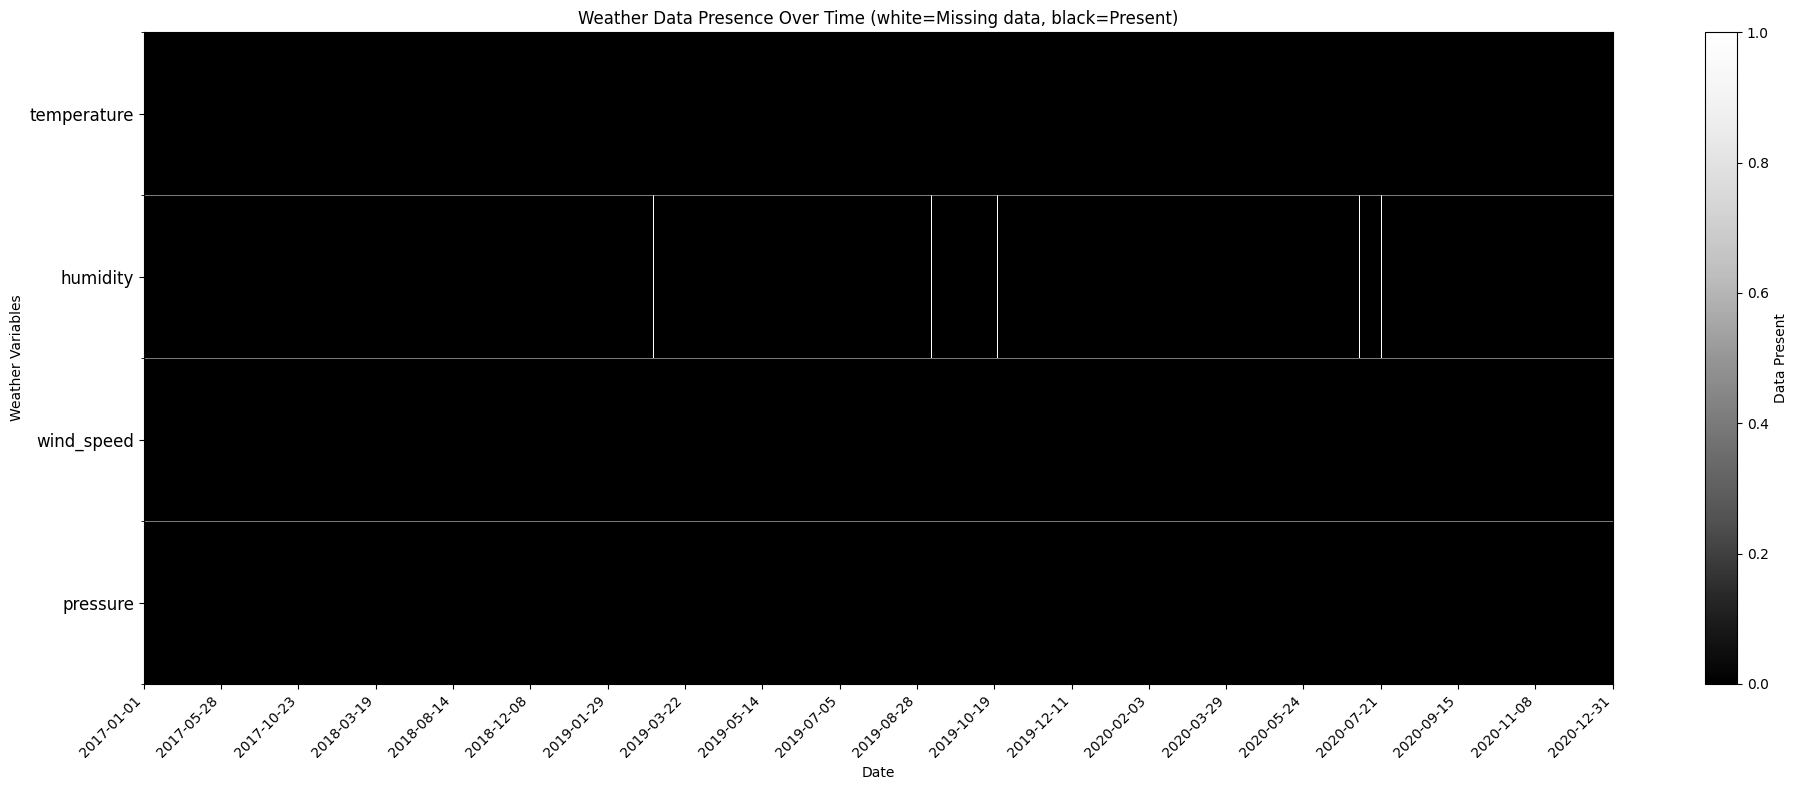


Weather variable data availability (percentage of time periods with data):
humidity: 99.6% available
pressure: 100.0% available
wind_speed: 100.0% available
temperature: 100.0% available

Overall missing data: 86 out of 89,780 possible measurements (0.10%)


In [7]:
# Visualize missing weather data over time
import matplotlib.pyplot as plt
import numpy as np

if time_cols and weather_cols:
    time_col = time_cols[0]
    
    # Convert time column to datetime if not already
    df_weather[time_col] = pd.to_datetime(df_weather[time_col], errors='coerce')
    
    # Set datetime as index for easier plotting
    df_weather_indexed = df_weather.set_index(time_col)
    
    # Check for missing values in weather columns
    missing_data = df_weather_indexed[weather_cols].isna()
    
    plt.figure(figsize=(20, 8))
    # Create visualization where black = data present, white = data missing
    plt.imshow(missing_data.T, aspect='auto', interpolation='none', cmap='Greys_r')
    plt.xlabel('Date')
    plt.ylabel('Weather Variables')
    plt.title('Weather Data Presence Over Time (white=Missing data, black=Present)')
    
    # Set x-ticks to show dates
    xticks = np.linspace(0, len(df_weather_indexed.index) - 1, min(20, len(df_weather_indexed.index))).astype(int)
    plt.xticks(xticks, [df_weather_indexed.index[i].strftime('%Y-%m-%d') if not pd.isnull(df_weather_indexed.index[i]) else '' for i in xticks], rotation=45, ha='right', fontsize=10)
    plt.yticks(np.arange(len(weather_cols)), weather_cols, fontsize=12)
    plt.gca().set_yticks(np.arange(-0.5, len(weather_cols), 1), minor=True)
    plt.gca().yaxis.grid(True, which='minor', linestyle='-', linewidth=0.5)
    plt.colorbar(label='Data Present')
    plt.tight_layout()
    plt.show()
    
    # Print statistics about missing data for each weather variable
    missing_stats = (1 - missing_data.mean()).sort_values()
    print("\nWeather variable data availability (percentage of time periods with data):")
    for variable in missing_stats.index:
        print(f"{variable}: {missing_stats[variable]*100:.1f}% available")
    
    # Print overall missing data summary
    total_missing = missing_data.sum().sum()
    total_possible = len(df_weather_indexed) * len(weather_cols)
    print(f"\nOverall missing data: {total_missing:,} out of {total_possible:,} possible measurements ({total_missing/total_possible*100:.2f}%)")
    
else:
    print("Required columns not found for this plot.")

# Comprehensive Missing Weather Data Summary

This section provides a complete analysis of missing meteorological data across all weather measurement variables.

In [8]:
# Comprehensive Missing Weather Data Analysis
import pandas as pd
import numpy as np
from datetime import timedelta

print("="*80)
print("COMPREHENSIVE MISSING WEATHER DATA SUMMARY")
print("="*80)

# Define the expected time range (2017-2020, 3-hourly data based on the sample)
start_date = pd.Timestamp('2017-01-01 00:00:00')
end_date = pd.Timestamp('2020-12-31 21:00:00')  # Assuming 3-hourly intervals
expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='3H')
expected_total_records = len(expected_datetime_range)

print(f"\n📅 EXPECTED DATA PERIOD:")
print(f"   Start: {start_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   End: {end_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Expected records per weather variable: {expected_total_records:,} (3-hourly data)")

# Convert datetime column
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])

# Get all weather measurement columns (excluding datetime)
weather_variables = [col for col in df_weather.columns if col != 'datetime']
total_variables = len(weather_variables)

print(f"\nWeather variables analyzed: {weather_variables}")

# 1. OVERALL STATISTICS
total_expected_measurements = expected_total_records * total_variables
total_actual_records = len(df_weather)
total_actual_measurements = df_weather[weather_variables].count().sum()
total_missing_measurements = total_expected_measurements - total_actual_measurements
missing_percentage = (total_missing_measurements / total_expected_measurements) * 100

print(f"\n📊 OVERALL STATISTICS:")
print(f"   Total weather variables: {total_variables}")
print(f"   Expected total measurements: {total_expected_measurements:,}")
print(f"   Actual records in dataset: {total_actual_records:,}")
print(f"   Available measurements: {total_actual_measurements:,}")
print(f"   Missing measurements: {total_missing_measurements:,}")
print(f"   Missing percentage: {missing_percentage:.2f}%")

# 2. MISSING DATA BY WEATHER VARIABLE
print(f"\n🌡️ MISSING DATA BY WEATHER VARIABLE:")
variable_missing_stats = []

for variable in weather_variables:
    variable_available_records = df_weather[variable].notna().sum()
    variable_missing_records = total_actual_records - variable_available_records
    variable_missing_pct = (variable_missing_records / total_actual_records) * 100
    
    variable_missing_stats.append({
        'variable': variable,
        'expected_records': total_actual_records,
        'available_records': variable_available_records,
        'missing_records': variable_missing_records,
        'missing_percentage': variable_missing_pct
    })

# Sort by missing percentage (descending)
variable_missing_df = pd.DataFrame(variable_missing_stats).sort_values('missing_percentage', ascending=False)

print(f"   {'Rank':<4} {'Variable':<12} {'Missing %':<10} {'Missing/Total':<15} {'Available':<10}")
print(f"   {'-'*4:<4} {'-'*12:<12} {'-'*10:<10} {'-'*15:<15} {'-'*10:<10}")

for i, row in variable_missing_df.iterrows():
    rank = variable_missing_df.index.get_loc(i) + 1
    print(f"   {rank:<4} {row['variable']:<12} {row['missing_percentage']:<10.1f} {row['missing_records']:>7,}/{row['expected_records']:<6,} {row['available_records']:>9,}")

# 3. TIME-BASED ANALYSIS
print(f"\n⏰ TIME-BASED MISSING DATA ANALYSIS:")

# For each year, calculate expected vs actual records
yearly_analysis = []
for year in range(2017, 2021):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end = pd.Timestamp(f'{year}-12-31 23:59:59')
    
    # Actual records for this year
    year_data = df_weather[
        (df_weather['datetime'] >= year_start) & 
        (df_weather['datetime'] <= year_end)
    ]
    year_actual_total = len(year_data)
    year_available_measurements = year_data[weather_variables].count().sum()
    year_possible_measurements = year_actual_total * total_variables
    year_missing_measurements = year_possible_measurements - year_available_measurements
    year_missing_pct = (year_missing_measurements / year_possible_measurements) * 100 if year_possible_measurements > 0 else 0
    
    yearly_analysis.append({
        'year': year,
        'records': year_actual_total,
        'possible_measurements': year_possible_measurements,
        'available_measurements': year_available_measurements,
        'missing_measurements': year_missing_measurements,
        'missing_percentage': year_missing_pct
    })

print(f"   Missing measurements by year (across all weather variables):")
print(f"   {'Year':<6} {'Records':<8} {'Missing %':<10} {'Missing/Possible':<16} {'Available':<10}")
print(f"   {'-'*6:<6} {'-'*8:<8} {'-'*10:<10} {'-'*16:<16} {'-'*10:<10}")
for analysis in yearly_analysis:
    print(f"   {analysis['year']:<6} {analysis['records']:<8,} {analysis['missing_percentage']:<10.1f} {analysis['missing_measurements']:>7,}/{analysis['possible_measurements']:<7,} {analysis['available_measurements']:>9,}")

# 4. BIGGEST TIME GAPS ANALYSIS
print(f"\n🕳️  BIGGEST TIME GAPS (Consecutive missing periods):")

def find_missing_gaps_weather(variable_name, top_n=5):
    """Find consecutive missing periods for a weather variable"""
    weather_data = df_weather[['datetime', variable_name]].copy()
    weather_data = weather_data.sort_values('datetime')
    weather_data['is_missing'] = weather_data[variable_name].isna()
    
    # Find consecutive missing periods
    weather_data['gap_group'] = (weather_data['is_missing'] != weather_data['is_missing'].shift()).cumsum()
    missing_groups = weather_data[weather_data['is_missing']].groupby('gap_group')
    
    gaps = []
    for group_id, group in missing_groups:
        if len(group) > 1:  # Only consider gaps longer than 1 record
            start_time = group['datetime'].min()
            end_time = group['datetime'].max()
            duration_records = len(group)
            duration_hours = duration_records * 3  # Assuming 3-hourly data
            duration_days = duration_hours / 24
            
            gaps.append({
                'variable': variable_name,
                'start': start_time,
                'end': end_time,
                'duration_records': duration_records,
                'duration_hours': duration_hours,
                'duration_days': duration_days
            })
    
    return sorted(gaps, key=lambda x: x['duration_records'], reverse=True)[:top_n]

# Find biggest gaps across all weather variables
all_gaps = []
for variable in weather_variables:
    gaps = find_missing_gaps_weather(variable, top_n=3)
    all_gaps.extend(gaps)

# Sort all gaps by duration
all_gaps = sorted(all_gaps, key=lambda x: x['duration_records'], reverse=True)[:10]

if all_gaps:
    print(f"   {'Rank':<4} {'Variable':<12} {'Start Date':<12} {'End Date':<12} {'Duration':<15}")
    print(f"   {'-'*4:<4} {'-'*12:<12} {'-'*12:<12} {'-'*12:<12} {'-'*15:<15}")

    for i, gap in enumerate(all_gaps, 1):
        start_str = gap['start'].strftime('%Y-%m-%d')
        end_str = gap['end'].strftime('%Y-%m-%d')
        if gap['duration_days'] >= 1:
            duration_str = f"{gap['duration_days']:.1f} days"
        else:
            duration_str = f"{gap['duration_hours']:.0f} hours"
        print(f"   {i:<4} {gap['variable']:<12} {start_str:<12} {end_str:<12} {duration_str:<15}")
else:
    print("   No significant gaps found in weather data")

# 5. WEATHER VARIABLE COMPLETENESS SUMMARY
print(f"\n📈 WEATHER VARIABLE COMPLETENESS SUMMARY:")
complete_variables = variable_missing_df[variable_missing_df['missing_percentage'] == 0.0]
mostly_complete = variable_missing_df[(variable_missing_df['missing_percentage'] > 0) & (variable_missing_df['missing_percentage'] <= 5)]
partially_missing = variable_missing_df[(variable_missing_df['missing_percentage'] > 5) & (variable_missing_df['missing_percentage'] <= 20)]
heavily_missing = variable_missing_df[variable_missing_df['missing_percentage'] > 20]

print(f"   Complete variables (0% missing): {len(complete_variables)} ({len(complete_variables)/total_variables*100:.1f}%)")
print(f"   Mostly complete (0-5% missing): {len(mostly_complete)} ({len(mostly_complete)/total_variables*100:.1f}%)")
print(f"   Partially missing (5-20% missing): {len(partially_missing)} ({len(partially_missing)/total_variables*100:.1f}%)")
print(f"   Heavily missing (>20% missing): {len(heavily_missing)} ({len(heavily_missing)/total_variables*100:.1f}%)")

# 6. TEMPORAL PATTERNS IN MISSING DATA
print(f"\n📅 TEMPORAL PATTERNS IN MISSING DATA:")

# Add time-based features
df_weather_temp = df_weather.copy()
df_weather_temp['year'] = df_weather_temp['datetime'].dt.year
df_weather_temp['month'] = df_weather_temp['datetime'].dt.month
df_weather_temp['hour'] = df_weather_temp['datetime'].dt.hour

# Missing data by month
monthly_missing = []
for month in range(1, 13):
    month_data = df_weather_temp[df_weather_temp['month'] == month]
    if len(month_data) > 0:
        month_missing_pct = (month_data[weather_variables].isna().sum().sum() / (len(month_data) * len(weather_variables))) * 100
        monthly_missing.append({'month': month, 'missing_pct': month_missing_pct})

print(f"   Missing data by month:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for data in monthly_missing:
    month_name = month_names[data['month']-1]
    print(f"   {month_name}: {data['missing_pct']:.1f}% missing")

print(f"\n" + "="*80)

COMPREHENSIVE MISSING WEATHER DATA SUMMARY

📅 EXPECTED DATA PERIOD:
   Start: 2017-01-01 00:00
   End: 2020-12-31 21:00
   Expected records per weather variable: 11,688 (3-hourly data)

Weather variables analyzed: ['temperature', 'humidity', 'wind_speed', 'pressure']

📊 OVERALL STATISTICS:
   Total weather variables: 4
   Expected total measurements: 46,752
   Actual records in dataset: 22,445
   Available measurements: 89,694
   Missing measurements: -42,942
   Missing percentage: -91.85%

🌡️ MISSING DATA BY WEATHER VARIABLE:
   Rank Variable     Missing %  Missing/Total   Available 
   ---- ------------ ---------- --------------- ----------
   1    humidity     0.4             81/22,445    22,364
   2    pressure     0.0              4/22,445    22,441
   3    wind_speed   0.0              1/22,445    22,444
   4    temperature  0.0              0/22,445    22,445

⏰ TIME-BASED MISSING DATA ANALYSIS:
   Missing measurements by year (across all weather variables):
   Year   Records  M

C:\Users\knuto\AppData\Local\Temp\ipykernel_59128\4259905883.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='3H')


# Measurement Frequency Analysis

This section analyzes how the measurement frequency changes over time, detecting transitions from 3-hourly to other intervals.

MEASUREMENT FREQUENCY ANALYSIS

📊 MEASUREMENT INTERVAL STATISTICS:
   Total measurements: 22,445
   Time intervals analyzed: 22,444
   Mean interval: 1.56 hours
   Median interval: 1.00 hours
   Standard deviation: 0.94 hours
   Min interval: 0.00 hours
   Max interval: 39.00 hours

⏱️  INTERVAL FREQUENCY DISTRIBUTION:
   Interval (hours) Count    Percentage   Cumulative %
   --------------- -------- ------------ ------------
   0.0             1        0.0          0.0         
   1.0             15,816   70.5         70.5        
   2.0             857      3.8          74.3        
   3.0             5,688    25.3         99.6        
   4.0             32       0.1          99.8        
   5.0             19       0.1          99.9        
   6.0             23       0.1          100.0       
   8.0             2        0.0          100.0       
   9.0             3        0.0          100.0       
   12.0            1        0.0          100.0       
   Other intervals 2        0.

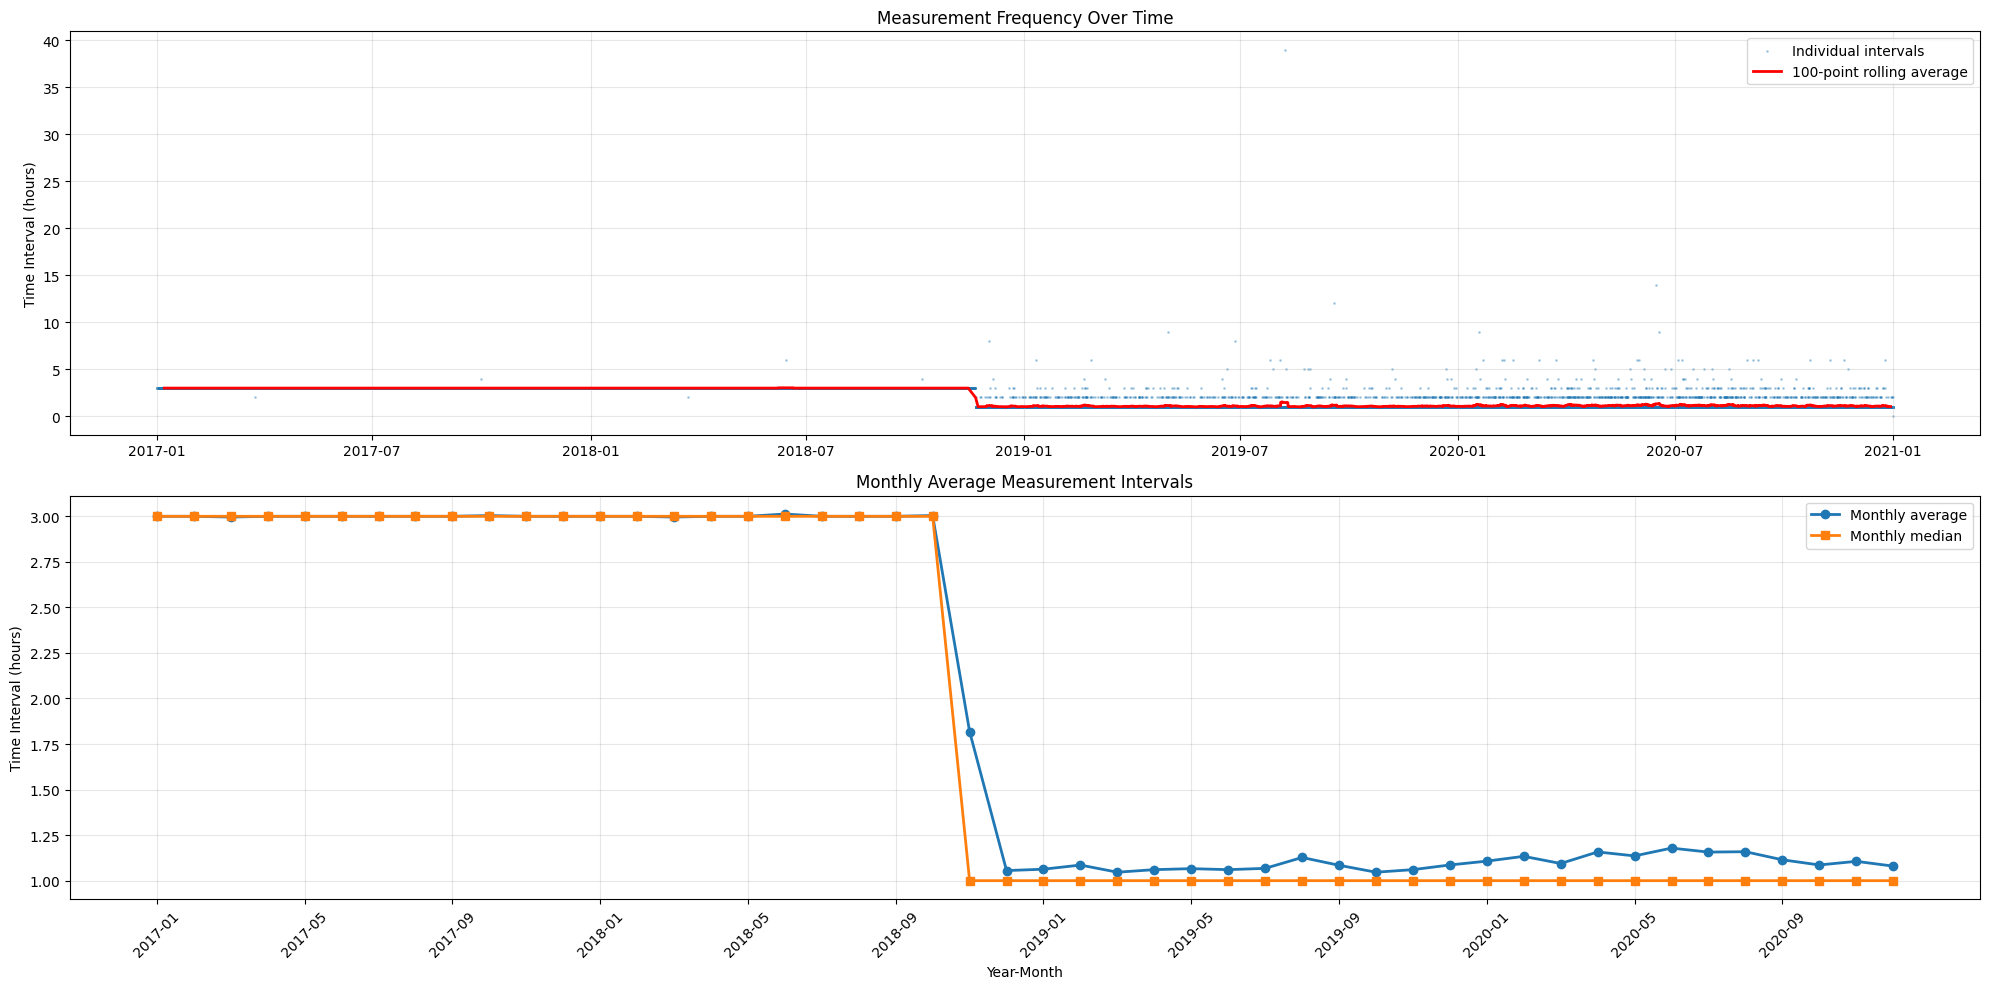


🎯 FREQUENCY STABILITY PERIODS:
   Found 2 stable frequency periods (3+ months):
   Period               Duration   Avg Interval
   -------------------- ---------- ------------
   2017-01 to 2018-10   22         3.0         
   2018-11 to 2020-12   26         1.0         



In [9]:
# Measurement Frequency Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("MEASUREMENT FREQUENCY ANALYSIS")
print("="*80)

# Sort the data by datetime to ensure proper order
df_weather_sorted = df_weather.sort_values('datetime').reset_index(drop=True)

# Calculate time differences between consecutive measurements
df_weather_sorted['time_diff'] = df_weather_sorted['datetime'].diff()

# Convert to hours for easier interpretation
df_weather_sorted['time_diff_hours'] = df_weather_sorted['time_diff'].dt.total_seconds() / 3600

# Remove the first NaN value
time_diffs = df_weather_sorted['time_diff_hours'].dropna()

print(f"\n📊 MEASUREMENT INTERVAL STATISTICS:")
print(f"   Total measurements: {len(df_weather_sorted):,}")
print(f"   Time intervals analyzed: {len(time_diffs):,}")
print(f"   Mean interval: {time_diffs.mean():.2f} hours")
print(f"   Median interval: {time_diffs.median():.2f} hours")
print(f"   Standard deviation: {time_diffs.std():.2f} hours")
print(f"   Min interval: {time_diffs.min():.2f} hours")
print(f"   Max interval: {time_diffs.max():.2f} hours")

# Analyze frequency distribution
print(f"\n⏱️  INTERVAL FREQUENCY DISTRIBUTION:")
interval_counts = time_diffs.value_counts().sort_index()
total_intervals = len(time_diffs)

print(f"   {'Interval (hours)':<15} {'Count':<8} {'Percentage':<12} {'Cumulative %':<12}")
print(f"   {'-'*15:<15} {'-'*8:<8} {'-'*12:<12} {'-'*12:<12}")

cumulative_pct = 0
for interval, count in interval_counts.head(10).items():
    percentage = (count / total_intervals) * 100
    cumulative_pct += percentage
    print(f"   {interval:<15.1f} {count:<8,} {percentage:<12.1f} {cumulative_pct:<12.1f}")

if len(interval_counts) > 10:
    remaining_count = interval_counts.iloc[10:].sum()
    remaining_pct = (remaining_count / total_intervals) * 100
    print(f"   {'Other intervals':<15} {remaining_count:<8,} {remaining_pct:<12.1f} {100.0:<12.1f}")

# Identify the transition points where frequency changes
print(f"\n🔄 MEASUREMENT FREQUENCY TRANSITIONS:")

# Create time periods for analysis
df_weather_sorted['year_month'] = df_weather_sorted['datetime'].dt.to_period('M')
monthly_intervals = df_weather_sorted.groupby('year_month')['time_diff_hours'].agg(['mean', 'median', 'std', 'count']).reset_index()
monthly_intervals['year_month_str'] = monthly_intervals['year_month'].astype(str)

# Detect significant changes in measurement frequency
frequency_changes = []
prev_median = None
change_threshold = 0.5  # hours

for idx, row in monthly_intervals.iterrows():
    current_median = row['median']
    if prev_median is not None and abs(current_median - prev_median) > change_threshold:
        frequency_changes.append({
            'period': row['year_month_str'],
            'previous_interval': prev_median,
            'new_interval': current_median,
            'change_hours': current_median - prev_median,
            'measurements_in_period': row['count']
        })
    prev_median = current_median

if frequency_changes:
    print(f"   Detected {len(frequency_changes)} significant frequency changes:")
    print(f"   {'Period':<10} {'From (hrs)':<10} {'To (hrs)':<10} {'Change':<10} {'Measurements':<12}")
    print(f"   {'-'*10:<10} {'-'*10:<10} {'-'*10:<10} {'-'*10:<10} {'-'*12:<12}")
    
    for change in frequency_changes:
        print(f"   {change['period']:<10} {change['previous_interval']:<10.1f} {change['new_interval']:<10.1f} {change['change_hours']:<+10.1f} {change['measurements_in_period']:<12}")
else:
    print("   No significant frequency changes detected")

# Time series analysis of measurement intervals
print(f"\n📈 TEMPORAL PATTERNS IN MEASUREMENT FREQUENCY:")

# Create rolling average of intervals
window_size = 100  # Use 100-measurement rolling window
df_weather_sorted['rolling_interval'] = df_weather_sorted['time_diff_hours'].rolling(window=window_size, center=True).mean()

# Plot the measurement intervals over time
plt.figure(figsize=(20, 10))

# Plot 1: Measurement intervals over time
plt.subplot(2, 1, 1)
plt.scatter(df_weather_sorted['datetime'], df_weather_sorted['time_diff_hours'], 
           alpha=0.3, s=1, label='Individual intervals')
plt.plot(df_weather_sorted['datetime'], df_weather_sorted['rolling_interval'], 
         color='red', linewidth=2, label=f'{window_size}-point rolling average')
plt.ylabel('Time Interval (hours)')
plt.title('Measurement Frequency Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Monthly average intervals
plt.subplot(2, 1, 2)
plt.plot(monthly_intervals['year_month'].astype(str), monthly_intervals['mean'], 
         marker='o', linewidth=2, label='Monthly average')
plt.plot(monthly_intervals['year_month'].astype(str), monthly_intervals['median'], 
         marker='s', linewidth=2, label='Monthly median')
plt.ylabel('Time Interval (hours)')
plt.xlabel('Year-Month')
plt.title('Monthly Average Measurement Intervals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Only show every 6th label to avoid crowding
ax = plt.gca()
ticks = ax.get_xticks()
if len(ticks) > 12:
    step = len(ticks) // 12
    ax.set_xticks(ticks[::step])

plt.tight_layout()
plt.show()

# Analysis of frequency stability periods
print(f"\n🎯 FREQUENCY STABILITY PERIODS:")

# Group consecutive periods with similar intervals
stability_threshold = 0.2  # hours
monthly_intervals['stable_group'] = (abs(monthly_intervals['median'].diff()) > stability_threshold).cumsum()

stable_periods = monthly_intervals.groupby('stable_group').agg({
    'year_month_str': ['first', 'last', 'count'],
    'median': 'mean'
}).round(2)

stable_periods.columns = ['start_period', 'end_period', 'duration_months', 'avg_interval']
stable_periods = stable_periods[stable_periods['duration_months'] >= 3]  # Only periods of 3+ months

if not stable_periods.empty:
    print(f"   Found {len(stable_periods)} stable frequency periods (3+ months):")
    print(f"   {'Period':<20} {'Duration':<10} {'Avg Interval':<12}")
    print(f"   {'-'*20:<20} {'-'*10:<10} {'-'*12:<12}")
    
    for idx, period in stable_periods.iterrows():
        period_str = f"{period['start_period']} to {period['end_period']}"
        print(f"   {period_str:<20} {period['duration_months']:<10.0f} {period['avg_interval']:<12.1f}")
else:
    print("   No stable frequency periods of 3+ months found")

print(f"\n" + "="*80)

In [10]:
# Detailed Analysis of Frequency Changes and Impact
print("="*80)
print("DETAILED FREQUENCY CHANGE IMPACT ANALYSIS")
print("="*80)

# Analyze data quality before and after frequency changes
if frequency_changes:
    print(f"\n🔍 DETAILED ANALYSIS OF EACH FREQUENCY CHANGE:")
    
    for i, change in enumerate(frequency_changes, 1):
        print(f"\n   📊 CHANGE #{i}: {change['period']}")
        print(f"   Interval change: {change['previous_interval']:.1f}h → {change['new_interval']:.1f}h ({change['change_hours']:+.1f}h)")
        
        # Get data before and after this change
        change_date = pd.Period(change['period']).start_time
        
        # Data from 2 months before the change
        before_start = change_date - pd.DateOffset(months=2)
        before_end = change_date - pd.DateOffset(days=1)
        before_data = df_weather_sorted[
            (df_weather_sorted['datetime'] >= before_start) & 
            (df_weather_sorted['datetime'] <= before_end)
        ]
        
        # Data from the change month and 1 month after
        after_start = change_date
        after_end = change_date + pd.DateOffset(months=2)
        after_data = df_weather_sorted[
            (df_weather_sorted['datetime'] >= after_start) & 
            (df_weather_sorted['datetime'] <= after_end)
        ]
        
        if len(before_data) > 0 and len(after_data) > 0:
            # Calculate statistics for before and after
            before_intervals = before_data['time_diff_hours'].dropna()
            after_intervals = after_data['time_diff_hours'].dropna()
            
            print(f"   Before change (2 months prior):")
            print(f"     - Measurements: {len(before_data):,}")
            print(f"     - Mean interval: {before_intervals.mean():.2f}h")
            print(f"     - Interval consistency (std): {before_intervals.std():.2f}h")
            
            print(f"   After change (2 months following):")
            print(f"     - Measurements: {len(after_data):,}")
            print(f"     - Mean interval: {after_intervals.mean():.2f}h")
            print(f"     - Interval consistency (std): {after_intervals.std():.2f}h")
            
            # Calculate data density change
            before_density = len(before_data) / ((before_end - before_start).days + 1)
            after_density = len(after_data) / ((after_end - after_start).days + 1)
            density_change = ((after_density - before_density) / before_density) * 100
            
            print(f"   Data density change: {density_change:+.1f}% (measurements per day)")

# Overall frequency evolution summary
print(f"\n📈 FREQUENCY EVOLUTION SUMMARY:")

# Calculate frequency for each year
yearly_frequency = df_weather_sorted.groupby(df_weather_sorted['datetime'].dt.year)['time_diff_hours'].agg(['mean', 'median', 'std', 'count'])

print(f"   {'Year':<6} {'Mean Interval':<13} {'Median Int.':<12} {'Std Dev':<10} {'Measurements':<12}")
print(f"   {'-'*6:<6} {'-'*13:<13} {'-'*12:<12} {'-'*10:<10} {'-'*12:<12}")

for year, stats in yearly_frequency.iterrows():
    print(f"   {year:<6} {stats['mean']:<13.2f} {stats['median']:<12.2f} {stats['std']:<10.2f} {stats['count']:<12,}")

# Recommendations based on frequency analysis
print(f"\n💡 RECOMMENDATIONS FOR DATA ANALYSIS:")

# Identify the most common stable interval
most_common_interval = time_diffs.mode().iloc[0] if len(time_diffs.mode()) > 0 else time_diffs.median()

print(f"   1. Most common measurement interval: {most_common_interval:.1f} hours")

if len(frequency_changes) > 0:
    print(f"   2. Data collection frequency changed {len(frequency_changes)} times during the study period")
    print(f"   3. Consider segmenting analysis by frequency periods for more accurate results")
    print(f"   4. When interpolating missing data, use period-appropriate intervals:")
    
    # Show recommended intervals by period
    for period_group in stable_periods.index if not stable_periods.empty else []:
        period_info = stable_periods.loc[period_group]
        print(f"      - {period_info['start_period']} to {period_info['end_period']}: {period_info['avg_interval']:.1f}h intervals")

else:
    print(f"   2. Data collection frequency was relatively stable throughout the period")
    print(f"   3. Consistent {most_common_interval:.1f}-hour intervals can be used for analysis and interpolation")

# Calculate potential impact on time-series analysis
irregular_intervals = time_diffs[abs(time_diffs - most_common_interval) > 0.5].count()
irregular_percentage = (irregular_intervals / len(time_diffs)) * 100

print(f"   5. {irregular_percentage:.1f}% of intervals deviate significantly from the standard")
if irregular_percentage > 10:
    print(f"   ⚠️  WARNING: High irregularity may affect time-series analysis accuracy")
elif irregular_percentage > 5:
    print(f"   ⚠️  CAUTION: Moderate irregularity - consider resampling for time-series analysis")
else:
    print(f"   ✅ Good: Low irregularity - suitable for most time-series analyses")

print(f"\n" + "="*80)

DETAILED FREQUENCY CHANGE IMPACT ANALYSIS

🔍 DETAILED ANALYSIS OF EACH FREQUENCY CHANGE:

   📊 CHANGE #1: 2018-11
   Interval change: 3.0h → 1.0h (-2.0h)
   Before change (2 months prior):
     - Measurements: 480
     - Mean interval: 3.00h
     - Interval consistency (std): 0.05h
   After change (2 months following):
     - Measurements: 1,103
     - Mean interval: 1.33h
     - Interval consistency (std): 0.75h
   Data density change: +126.1% (measurements per day)

📈 FREQUENCY EVOLUTION SUMMARY:
   Year   Mean Interval Median Int.  Std Dev    Measurements
   ------ ------------- ------------ ---------- ------------
   2017   3.00          3.00         0.03       2,919.0     
   2018   2.48          3.00         0.88       3,533.0     
   2019   1.07          1.00         0.55       8,182.0     
   2020   1.12          1.00         0.51       7,810.0     

💡 RECOMMENDATIONS FOR DATA ANALYSIS:
   1. Most common measurement interval: 1.0 hours
   2. Data collection frequency changed 1 